<Axes: ylabel='Reconstruction loss'>

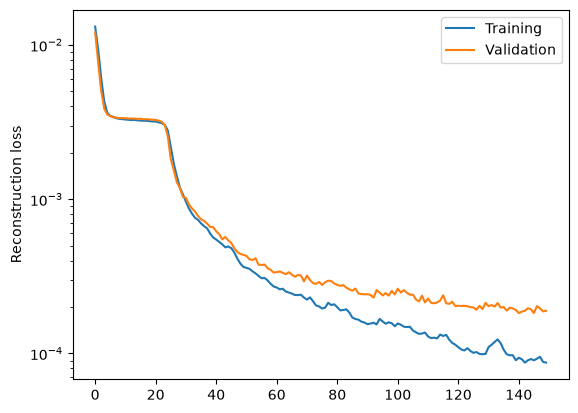

In [45]:
import pandas as pd
import matplotlib.pyplot as plt

fig, ax = plt.subplots()
ax.set(ylabel='Reconstruction loss', yscale='log')

df = pd.read_csv("ae_metrics.csv")
df.plot(y='train_loss', label='Training', ax=ax)
df.plot(y='validation_loss', label='Validation', ax=ax)

# Reconstruction of the validation dataset

In [46]:
import torch
from torch.utils.data import DataLoader

from modules.model import Autoencoder
from modules.dataset import LogMinMaxScale, EnsembleDataset
from modules.generation import reconstruct_samples, save_reconstructions

checkpoint = torch.load('output/ae06.pt', map_location='cpu')

## Normalization
min_value = checkpoint['MINVAL']
max_value = checkpoint['MAXVAL']
scale     = checkpoint['SCALE']
transform = LogMinMaxScale(min_value, max_value, scale)

# Model
model = Autoencoder(checkpoint['LATENT_DIM'], in_shape=checkpoint['IN_SHAPE'])
model.load_state_dict(checkpoint['model_state_dict'])

<All keys matched successfully>

In [47]:
import xarray as xr

fname = checkpoint['FNAME_VAL']
varkey = checkpoint['VARKEY']

## Loading raw data and normaliation
ds = xr.open_dataset(fname)
da = ds[varkey]

dataset = EnsembleDataset(da, transform)
loader  = DataLoader(dataset, batch_size=12,shuffle=False)

In [48]:
fname = "output/recon_ae06.nc"
reconstructions, targets = reconstruct_samples(model,loader,transform)
save_reconstructions(fname,reconstructions, targets)

In [49]:
import numpy as np

for i in range(6):
    fname = f"output/recon_ae{i+1:02d}.nc"
    ds = xr.open_dataset(fname)
    e2 = (ds['target']-ds['reconstruction'])**2
    mse = e2.mean().item()
    rmse = np.sqrt(mse)
    print(rmse)
    ds.close()

0.031240710539258067
0.03850990831621773
0.04323049499202079
0.04350110695952443
0.036687117505557254
0.03584210949941704


# Model summary

In [10]:
from torchsummary import summary
H,W = checkpoint['IN_SHAPE']
summary(model, (1,H,W))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1          [-1, 16, 64, 128]             160
              ReLU-2          [-1, 16, 64, 128]               0
            Conv2d-3           [-1, 32, 32, 64]           4,640
              ReLU-4           [-1, 32, 32, 64]               0
            Conv2d-5           [-1, 64, 16, 32]          18,496
              ReLU-6           [-1, 64, 16, 32]               0
            Conv2d-7           [-1, 128, 8, 16]          73,856
              ReLU-8           [-1, 128, 8, 16]               0
           Flatten-9                [-1, 16384]               0
           Linear-10                   [-1, 64]       1,048,640
           Linear-11                [-1, 16384]       1,064,960
             ReLU-12                [-1, 16384]               0
        Unflatten-13           [-1, 128, 8, 16]               0
         Upsample-14          [-1, 128,